# SETTING UP ACCESS TO GITHUB (PRESERVED STATE) FOR EVERY NEW RUNTIME

In [1]:
from google.colab import userdata
import os

git_token = userdata.get('GIT_TOKEN')
git_username = "TalhaShoyo10"
repo_name = "CS-6304_PA0_28100131"
repo_url = f"https://{git_token}@github.com/{git_username}/{repo_name}.git"



if not os.path.exists(repo_name):
  !git clone {repo_url}
  print("Repo did not exist in local file system, cloned from github to initiate work on task.")
else:
  !git -C {repo_name} pull
  print("Repo already existed in local file system, pulled from github to catch up on any remote changes.")

Cloning into 'CS-6304_PA0_28100131'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 69 (delta 20), reused 20 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (69/69), 187.36 KiB | 4.80 MiB/s, done.
Resolving deltas: 100% (20/20), done.
Repo did not exist in local file system, cloned from github to initiate work on task.


Imports and Setup


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import json
import os
import torch.nn.functional as F
from sklearn.manifold import TSNE


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# BASELINE SETUP


DATA PREPARATION AND LOADING

In [3]:
#Applying the input size and normalisation transformations native to ImageNet on CIFAR-10 images
#As that is what the pretrained ResNet architecture is designed to work with
transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

total_train_dataset = torchvision.datasets.CIFAR10(root = './data', train = True, download = True, transform = transform)
test_dataset = torchvision.datasets.CIFAR10(root = './data', train = False, download = True, transform=transform)

BATCH_SIZE = 64
VAL_SIZE = 5000
TRAIN_SIZE = len(total_train_dataset) - VAL_SIZE

# Verifying the 50,000 : 10,000 training to test data ratio for CIFAR-10
print(f"Number of Training examples: {len(total_train_dataset)}")
print(f"Number of Testing examples: {len(test_dataset)}")

# Verifying the classes are as documented for teh CIFAR-10 dataset
classes = total_train_dataset.classes
print(f"Classes: {classes}")

#Creating the practical train and validation datasets
train_dataset, val_dataset = torch.utils.data.random_split(total_train_dataset, [TRAIN_SIZE, VAL_SIZE],  generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Number of Training batches: {len(train_loader)}")
print(f"Number of Validation batches: {len(val_loader)}")
print(f"Number of Testing batches: {len(test_loader)}")


100%|██████████| 170M/170M [22:32<00:00, 126kB/s]


Number of Training examples: 50000
Number of Testing examples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of Training batches: 704
Number of Validation batches: 79
Number of Testing batches: 157


Loading pretrained ResNet-152, Freezing BackBone, Setting up Trainable Classification Head

In [4]:
#Loading pretrained ImageNet ResNet architecture
model = torchvision.models.resnet152(weights=torchvision.models.ResNet152_Weights.IMAGENET1K_V2)

#Freezing the Backbone
for para in model.parameters() :
  para.requires_grad = False

#Setting up the custom final classification layer
classes = 10
model.fc = nn.Linear(model.fc.in_features, classes)
model = model.to(device)

#Checking count of trainable parameters
trainable_paras = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {trainable_paras}")
#Checking count of all parameters to ensure trainable parameters are less than all parameters in count
total_para = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_para}")

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 169MB/s]


Number of trainable parameters: 20490
Total number of parameters: 58164298


Train and Evaluate Functions

In [5]:
def train(model, loader, criterion, optimizer, epoch_num, total_epochs):
  model.train()
  running_loss = 0.0
  correct = 0
  total = 0

  for batch_index , (images, labels) in enumerate(loader):
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    results = model(images)
    loss = criterion(results, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * images.size(0)
    predicted_values, predicted_indices = torch.max(results, 1)
    correct += (predicted_indices == labels).sum().item()
    total += labels.size(0)

    if batch_index % 100 == 0:
      print(f"Epoch {epoch_num+1}/{total_epochs}, Batch {batch_index}/{len(loader)}, Loss: {loss.item():.4f}")

  avg_train_loss = running_loss / total
  train_acc = correct / total
  return avg_train_loss, train_acc



def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            results = model(images)
            loss = criterion(results, labels)

            running_loss += loss.item() * images.size(0)
            predicted_values, predicted_indices = torch.max(results, 1)
            correct += (predicted_indices == labels).sum().item()
            total += labels.size(0)

    avg_eval_loss = running_loss / total
    eval_acc = correct / total
    return avg_eval_loss, eval_acc

Training Loop

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
EPOCHS = 5

history = {'train_loss': [], 'train_acc': [],'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, epoch, EPOCHS)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/5, Batch 0/704, Loss: 2.2970
Epoch 1/5, Batch 100/704, Loss: 0.9118
Epoch 1/5, Batch 200/704, Loss: 0.7807
Epoch 1/5, Batch 300/704, Loss: 0.8234
Epoch 1/5, Batch 400/704, Loss: 0.6250
Epoch 1/5, Batch 500/704, Loss: 0.6338
Epoch 1/5, Batch 600/704, Loss: 0.5464
Epoch 1/5, Batch 700/704, Loss: 0.3714
Epoch 1/5
Train Loss: 0.7182, Train Acc: 0.7802
Val Loss: 0.5076, Val Acc: 0.8328
Epoch 2/5, Batch 0/704, Loss: 0.4936
Epoch 2/5, Batch 100/704, Loss: 0.6579
Epoch 2/5, Batch 200/704, Loss: 0.4592
Epoch 2/5, Batch 300/704, Loss: 0.4797
Epoch 2/5, Batch 400/704, Loss: 0.4210
Epoch 2/5, Batch 500/704, Loss: 0.5594
Epoch 2/5, Batch 600/704, Loss: 0.3798
Epoch 2/5, Batch 700/704, Loss: 0.4929
Epoch 2/5
Train Loss: 0.4994, Train Acc: 0.8347
Val Loss: 0.4666, Val Acc: 0.8410
Epoch 3/5, Batch 0/704, Loss: 0.6200
Epoch 3/5, Batch 100/704, Loss: 0.3102
Epoch 3/5, Batch 200/704, Loss: 0.5284
Epoch 3/5, Batch 300/704, Loss: 0.6909
Epoch 3/5, Batch 400/704, Loss: 0.7069
Epoch 3/5, Batch 500/70

Loss and Accuracy Plots (For Training and Validation)

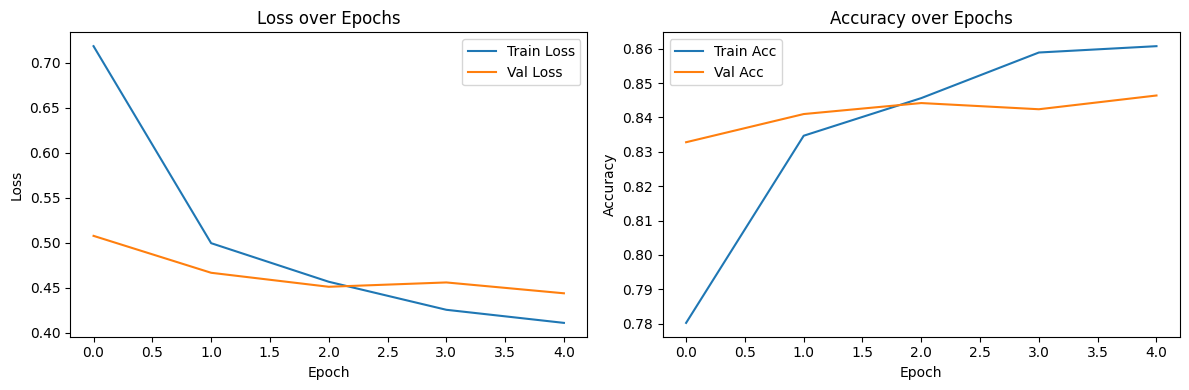

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over Epochs')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].legend()

plt.tight_layout()
plt.savefig('CS-6304_PA0_28100131/results/task1_resnet/baseline_training.png', dpi=150)
plt.show()

Test Dataset Evaluation

In [8]:
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")

Final Test Loss: 0.4529
Final Test Accuracy: 0.8526


Saving Results

In [9]:
results = {
    'history': history,
    'final_train_acc': history['train_acc'][-1],
    'final_val_acc': history['val_acc'][-1],
    'final_test_acc': test_acc,
    'final_test_loss': test_loss,
    'num_epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'optimizer': 'Adam',
    'learning_rate': 0.001
}

with open('CS-6304_PA0_28100131/results/task1_resnet/baseline_results.json', 'w') as f:
    json.dump(results, f, indent=2)

torch.save(model.fc.state_dict(), 'CS-6304_PA0_28100131/results/task1_resnet/baseline_head_weights.pt')

print("Resuls Saved Successfully !!")

Resuls Saved Successfully !!


Checking for Saved Files

In [10]:
print(os.listdir('CS-6304_PA0_28100131/results/task1_resnet'))

['baseline_results.json', 'baseline_training.png', 'baseline_head_weights.pt', '.gitkeep']


# INVESTIGATING IMPACT OF SKIP CONNECTIONS

Modifying Bottleneck Block to exclude Skip Connection

In [11]:
from torchvision.models.resnet import Bottleneck
#Identical to torchvison's bottlneck block structure, except for the skip connection (out += identity), which is removed from teh forward pass
class BottleneckNoSkip(Bottleneck):
    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)
        out = self.relu(out)
        return out

Building the ablation(modified) model

In [12]:
modified_model = torchvision.models.resnet152(weights=torchvision.models.ResNet152_Weights.IMAGENET1K_V2)

def no_skip_block(bottleneck_block):
  bottleneck_block.__class__ = BottleneckNoSkip
  return bottleneck_block

modified_model.layer1[0] = no_skip_block(modified_model.layer1[0])
modified_model.layer2[0] = no_skip_block(modified_model.layer2[0])
modified_model.layer4[0] = no_skip_block(modified_model.layer4[0])

print("Modified the first bottleneck blocks of Layers 1, 2 and 4 to remove their skip connections")

Modified the first bottleneck blocks of Layers 1, 2 and 4 to remove their skip connections


Gradient Diagnostic - Checking the ratio between early layer gradients of a model with all skip connections present and a model with some skip connections removed

In [13]:
#Grabbing one batch to test with
batch_images, batch_labels = next(iter(train_loader))
batch_images, batch_labels = batch_images.to(device), batch_labels.to(device)
criterion = nn.CrossEntropyLoss()

def early_layer_gradient(test_model, images, labels, criterion, model_title):
  for para in test_model.parameters():
    para.requires_grad = True

  test_model = test_model.to(device)
  test_model.train()

  for para in test_model.parameters():
    if para.grad is not None :
      para.grad = None

  results = test_model(images)
  loss = criterion(results, labels)
  loss.backward()

  early_layer_grad_norm = test_model.layer1[0].conv1.weight.grad.norm().item()

  print(f"Model : {model_title}")
  print(f"Early Layer Gradient Norm: {early_layer_grad_norm}")
  print("")

  for para in test_model.parameters():
    para.requires_grad = False

  return early_layer_grad_norm

intact_model = torchvision.models.resnet152(weights=torchvision.models.ResNet152_Weights.IMAGENET1K_V2)

no_skip_grad_norm = early_layer_gradient(modified_model, batch_images, batch_labels, criterion, "Modified Model(skip connections removed from first bottleneck blocks of layers 1, 2 and 4)")
skip_grad_norm = early_layer_gradient(intact_model, batch_images, batch_labels, criterion, "Base Model(skip connections still maintained for first bottleneck blocks of layers 1, 2 and 4)")

print (f"Early Layer Gradient Norm Ratio (Modified / Original) ---- {no_skip_grad_norm / skip_grad_norm :.4f}")

Model : Modified Model(skip connections removed from first bottleneck blocks of layers 1, 2 and 4)
Early Layer Gradient Norm: 3.939354419708252

Model : Base Model(skip connections still maintained for first bottleneck blocks of layers 1, 2 and 4)
Early Layer Gradient Norm: 4.535881042480469

Early Layer Gradient Norm Ratio (Modified / Original) ---- 0.8685


Comparing training dynamics and validation accuracy of modified model(some removed skip connections) with the baseline(no removed skip connections)

Preparing the modified model's trainable head

In [14]:
for para in modified_model.parameters():
    para.requires_grad = False

num_classes = 10
modified_model.fc = nn.Linear(modified_model.fc.in_features, num_classes)
modified_model = modified_model.to(device)

modified_trainable_paras = sum(p.numel() for p in modified_model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {modified_trainable_paras}")

modified_total_paras = sum(p.numel() for p in modified_model.parameters())
print(f"Total number of parameters: {modified_total_paras}")

Number of trainable parameters: 20490
Total number of parameters: 58164298


Training modified model's head

In [15]:
criterion = nn.CrossEntropyLoss()
modified_optimizer = optim.Adam(modified_model.fc.parameters(), lr=0.001)
EPOCHS = 5

modified_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train(modified_model, train_loader, criterion, modified_optimizer, epoch, EPOCHS)
    val_loss, val_acc = evaluate(modified_model, val_loader, criterion)

    modified_history['train_loss'].append(train_loss)
    modified_history['train_acc'].append(train_acc)
    modified_history['val_loss'].append(val_loss)
    modified_history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/5, Batch 0/704, Loss: 2.3087
Epoch 1/5, Batch 100/704, Loss: 2.1583
Epoch 1/5, Batch 200/704, Loss: 2.0253
Epoch 1/5, Batch 300/704, Loss: 1.9311
Epoch 1/5, Batch 400/704, Loss: 2.1110
Epoch 1/5, Batch 500/704, Loss: 1.9001
Epoch 1/5, Batch 600/704, Loss: 1.9790
Epoch 1/5, Batch 700/704, Loss: 1.8593
Epoch 1/5
Train Loss: 1.9834, Train Acc: 0.3483
Val Loss: 1.8313, Val Acc: 0.3962
Epoch 2/5, Batch 0/704, Loss: 1.8105
Epoch 2/5, Batch 100/704, Loss: 1.7696
Epoch 2/5, Batch 200/704, Loss: 1.6996
Epoch 2/5, Batch 300/704, Loss: 1.5730
Epoch 2/5, Batch 400/704, Loss: 1.9591
Epoch 2/5, Batch 500/704, Loss: 1.7150
Epoch 2/5, Batch 600/704, Loss: 1.6901
Epoch 2/5, Batch 700/704, Loss: 1.7511
Epoch 2/5
Train Loss: 1.7444, Train Acc: 0.4150
Val Loss: 1.7177, Val Acc: 0.4218
Epoch 3/5, Batch 0/704, Loss: 1.4854
Epoch 3/5, Batch 100/704, Loss: 1.8405
Epoch 3/5, Batch 200/704, Loss: 1.5162
Epoch 3/5, Batch 300/704, Loss: 1.7392
Epoch 3/5, Batch 400/704, Loss: 1.4868
Epoch 3/5, Batch 500/70

Loss and Accuracy curves for modified model (Training and Validation)

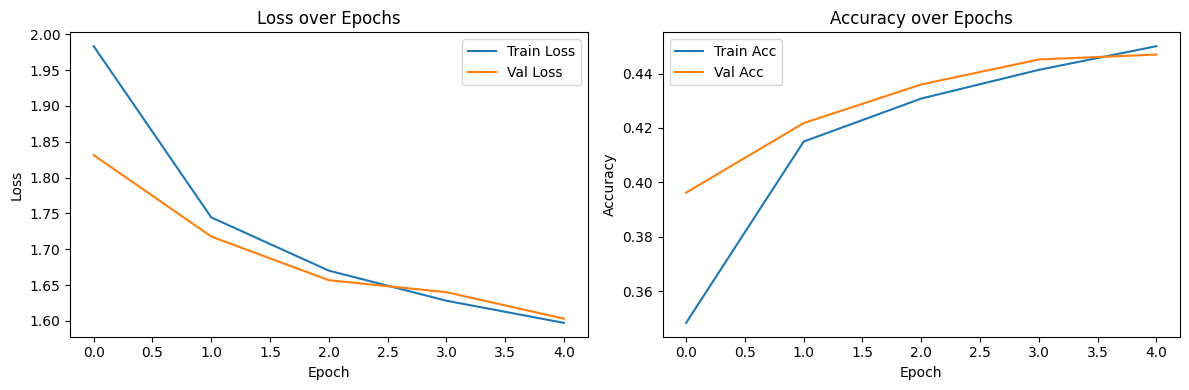

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(modified_history['train_loss'], label='Train Loss')
axes[0].plot(modified_history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over Epochs')
axes[0].legend()

axes[1].plot(modified_history['train_acc'], label='Train Acc')
axes[1].plot(modified_history['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].legend()

plt.tight_layout()
plt.savefig('CS-6304_PA0_28100131/results/task1_resnet/modified_training.png', dpi=150)
plt.show()

Test Dataset Evaluation (modified model)

In [17]:
modified_test_loss, modified_test_acc = evaluate(modified_model, test_loader, criterion)
print(f"Final Test Loss: {modified_test_loss:.4f}")
print(f"Final Test Accuracy: {modified_test_acc:.4f}")

Final Test Loss: 1.6135
Final Test Accuracy: 0.4379


Saving results for modified model

In [18]:
modified_results = {
    'history': modified_history,
    'final_train_acc': modified_history['train_acc'][-1],
    'final_val_acc': modified_history['val_acc'][-1],
    'final_test_acc': modified_test_acc,
    'final_test_loss': modified_test_loss,
    'blocks_modified': ['layer1[0]', 'layer2[0]', 'layer4[0]'],
    'gradient_diagnostic': {
        'intact_grad_norm': skip_grad_norm,
        'modified_grad_norm': no_skip_grad_norm,
        'ratio': no_skip_grad_norm / skip_grad_norm
    },
    'num_epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'optimizer': 'Adam',
    'learning_rate': 0.001
}

with open('CS-6304_PA0_28100131/results/task1_resnet/modified_results.json', 'w') as f:
    json.dump(modified_results, f, indent=2)

torch.save(modified_model.fc.state_dict(), 'CS-6304_PA0_28100131/results/task1_resnet/modified_head_weights.pt')

print("modified results saved.")

modified results saved.


Checking for Saved Files

In [19]:
print(os.listdir('CS-6304_PA0_28100131/results/task1_resnet'))

['baseline_results.json', 'baseline_training.png', 'modified_training.png', 'baseline_head_weights.pt', 'modified_head_weights.pt', '.gitkeep', 'modified_results.json']


# FEATURE HIERARCHIES AND REPRESENTATIONS

TSNE Visualisation Helper

In [22]:
def plot_tsne(features, labels, title="t-SNE projection", save_path=None):
    """
    N : Number of image samples , D : Dimensions of the feature map/vector for each sample
    features: (N, D) array of Layer Representations
    labels: (N,) array of class labels for coloring
    """
    reduced = TSNE(n_components=2, init="pca", random_state=0).fit_transform(features)
    plt.figure(figsize=(7, 6))
    scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap="tab10", s=10, alpha=0.7)
    plt.legend(*scatter.legend_elements(), title="Class", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

Reload Trained Baseline Model

In [23]:
reloaded_model = torchvision.models.resnet152(weights=torchvision.models.ResNet152_Weights.IMAGENET1K_V2)

for para in reloaded_model.parameters():
    para.requires_grad = False

num_classes = 10
reloaded_model.fc = nn.Linear(reloaded_model.fc.in_features, num_classes)

reloaded_model = reloaded_model.to(device)
reloaded_model.fc.load_state_dict(torch.load('CS-6304_PA0_28100131/results/task1_resnet/baseline_head_weights.pt'))

reloaded_model.eval()
print("Baseline model reconstructed and trained head weights loaded.")

Baseline model reconstructed and trained head weights loaded.


Register Forward Hooks

In [24]:
captured_features = {}

def make_hook(layer_name):
    def hook(module, input, output):
        captured_features[layer_name] = output
    return hook

hook_early = reloaded_model.layer1.register_forward_hook(make_hook('early'))
hook_middle = reloaded_model.layer3.register_forward_hook(make_hook('middle'))
hook_late = reloaded_model.layer4.register_forward_hook(make_hook('late'))

print("Hooks registered on layer1 (early), layer3 (middle), layer4 (late)")

Hooks registered on layer1 (early), layer3 (middle), layer4 (late)


Run a Batch to Capture Features

In [25]:
feature_images, feature_labels = next(iter(val_loader))
feature_images = feature_images.to(device)

with torch.no_grad():
   output = reloaded_model(feature_images)

print("Shapes of captured feature maps:")
for name, feat in captured_features.items():
    print("")
    print(f"{name}: {feat.shape}")
    print("")

Shapes of captured feature maps:

early: torch.Size([64, 256, 56, 56])


middle: torch.Size([64, 1024, 14, 14])


late: torch.Size([64, 2048, 7, 7])



Visualising feature maps at progressive model stages using t-SNE

early layer — flattened feature dimensionality: 256


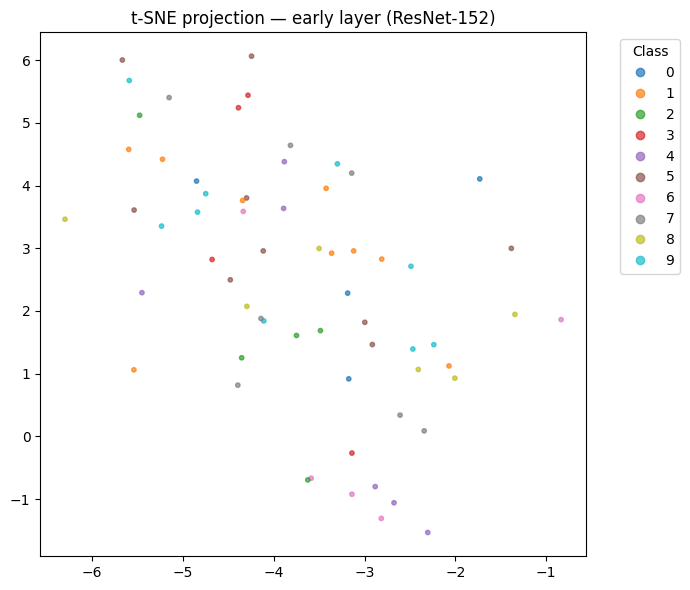

middle layer — flattened feature dimensionality: 1024


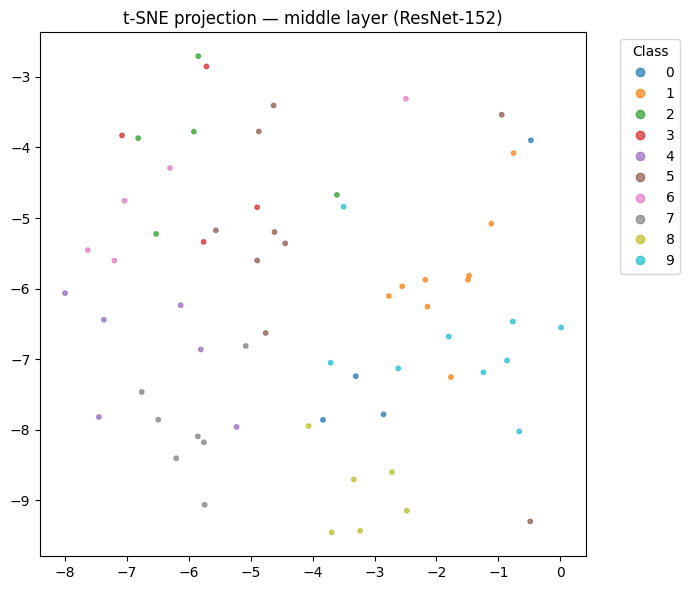

late layer — flattened feature dimensionality: 2048


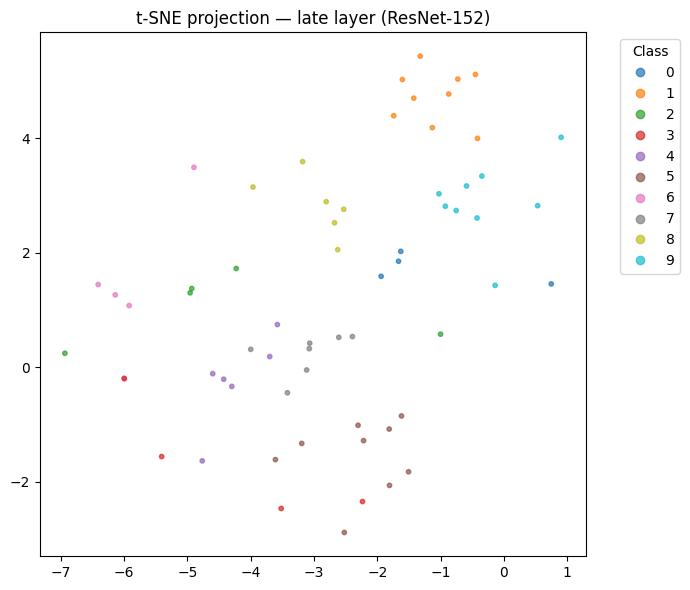

In [26]:
def features_for_tsne(raw_features):
    pooled = F.adaptive_avg_pool2d(raw_features, (1, 1))
    flattened = pooled.view(pooled.size(0), -1)
    return flattened.cpu().numpy()

feature_labels_np = feature_labels.numpy()

for layer_name in ['early', 'middle', 'late']:
    features_np = features_for_tsne(captured_features[layer_name])
    print(f"{layer_name} layer — flattened feature dimensionality: {features_np.shape[1]}")

    plot_tsne(features_np, feature_labels_np, title=f"t-SNE projection — {layer_name} layer (ResNet-152)", save_path=f"CS-6304_PA0_28100131/results/task1_resnet/tsne_{layer_name}.png")

Checking for Saved Files

In [27]:
print(os.listdir('CS-6304_PA0_28100131/results/task1_resnet'))

['baseline_results.json', 'tsne_late.png', 'baseline_training.png', 'tsne_early.png', 'modified_training.png', 'baseline_head_weights.pt', 'modified_head_weights.pt', '.gitkeep', 'tsne_middle.png', 'modified_results.json']


Removing Hooks (Per Convention , Not Necessary for this one-off instance)

In [28]:
hook_early.remove()
hook_middle.remove()
hook_late.remove()
print("Hooks removed.")

Hooks removed.


# TRANSFER LEARNING AND GENERALIZATION

Building 4 model variants: pretrained/random-init x final-block-only/full-backbone

In [29]:
def build_transfer_model(pretrained, unfreeze_full_backbone):
    if pretrained:
        net = torchvision.models.resnet152(weights=torchvision.models.ResNet152_Weights.IMAGENET1K_V2)
    else:
        net = torchvision.models.resnet152(weights=None)

    for para in net.parameters():
        para.requires_grad = False

    if unfreeze_full_backbone:
        for para in net.parameters():
            para.requires_grad = True
    else:
        for para in net.layer4.parameters():
            para.requires_grad = True

    num_classes = 10
    net.fc = nn.Linear(net.fc.in_features, num_classes)
    net = net.to(device)
    return net


Run A: Pretrained, final block only

In [53]:
model_a = build_transfer_model(pretrained=True, unfreeze_full_backbone=False)
trainable_a = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
print(f"Run A trainable parameters: {trainable_a:,}")

Run A trainable parameters: 14,985,226


Run B: Pretrained, full backbone

In [52]:
model_b = build_transfer_model(pretrained=True, unfreeze_full_backbone=True)
trainable_b = sum(p.numel() for p in model_b.parameters() if p.requires_grad)
print(f"Run B trainable parameters: {trainable_b:,}")

Run B trainable parameters: 58,164,298


Run C: Random init, full backbone

In [56]:
model_c = build_transfer_model(pretrained=False, unfreeze_full_backbone=True)
trainable_c = sum(p.numel() for p in model_c.parameters() if p.requires_grad)
print(f"Run C trainable parameters: {trainable_c:,}")

Run C trainable parameters: 58,164,298


Run D: Random init, final block only

In [33]:
model_d = build_transfer_model(pretrained=False, unfreeze_full_backbone=False)
trainable_d = sum(p.numel() for p in model_d.parameters() if p.requires_grad)
print(f"Run D trainable parameters: {trainable_d:,}")

Run D trainable parameters: 14,985,226


Training all 4 runs

In [35]:
def run_transfer_experiment(net, run_name, epochs=3, lr=0.0001):
    criterion = nn.CrossEntropyLoss()
    trainable_params = [p for p in net.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=lr)

    run_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        train_loss, train_acc = train(net, train_loader, criterion, optimizer, epoch, epochs)
        val_loss, val_acc = evaluate(net, val_loader, criterion)

        run_history['train_loss'].append(train_loss)
        run_history['train_acc'].append(train_acc)
        run_history['val_loss'].append(val_loss)
        run_history['val_acc'].append(val_acc)

        print(f"[{run_name}] Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    test_loss, test_acc = evaluate(net, test_loader, criterion)
    print(f"[{run_name}] Final Test Loss: {test_loss:.4f}, Final Test Accuracy: {test_acc:.4f}")

    return run_history, test_loss, test_acc


In [36]:
history_a, test_loss_a, test_acc_a = run_transfer_experiment(model_a, "Run A: Pretrained, Final Block Only")

Epoch 1/3, Batch 0/704, Loss: 2.3619
Epoch 1/3, Batch 100/704, Loss: 0.7966
Epoch 1/3, Batch 200/704, Loss: 0.4375
Epoch 1/3, Batch 300/704, Loss: 0.2680
Epoch 1/3, Batch 400/704, Loss: 0.3703
Epoch 1/3, Batch 500/704, Loss: 0.3147
Epoch 1/3, Batch 600/704, Loss: 0.4286
Epoch 1/3, Batch 700/704, Loss: 0.5106
[Run A: Pretrained, Final Block Only] Epoch 1/3
Train Loss: 0.5310, Train Acc: 0.8341
Val Loss: 0.3067, Val Acc: 0.8942
Epoch 2/3, Batch 0/704, Loss: 0.1257
Epoch 2/3, Batch 100/704, Loss: 0.1875
Epoch 2/3, Batch 200/704, Loss: 0.3307
Epoch 2/3, Batch 300/704, Loss: 0.3062
Epoch 2/3, Batch 400/704, Loss: 0.1757
Epoch 2/3, Batch 500/704, Loss: 0.2876
Epoch 2/3, Batch 600/704, Loss: 0.0647
Epoch 2/3, Batch 700/704, Loss: 0.4134
[Run A: Pretrained, Final Block Only] Epoch 2/3
Train Loss: 0.2049, Train Acc: 0.9320
Val Loss: 0.2851, Val Acc: 0.9080
Epoch 3/3, Batch 0/704, Loss: 0.0961
Epoch 3/3, Batch 100/704, Loss: 0.0796
Epoch 3/3, Batch 200/704, Loss: 0.1557
Epoch 3/3, Batch 300/704,

In [54]:
del model_a
torch.cuda.empty_cache()

In [40]:
history_b, test_loss_b, test_acc_b = run_transfer_experiment(model_b, "Run B: Pretrained, Full Backbone")

Epoch 1/3, Batch 0/704, Loss: 2.3013
Epoch 1/3, Batch 100/704, Loss: 0.3139
Epoch 1/3, Batch 200/704, Loss: 0.1605
Epoch 1/3, Batch 300/704, Loss: 0.1682
Epoch 1/3, Batch 400/704, Loss: 0.0348
Epoch 1/3, Batch 500/704, Loss: 0.0923
Epoch 1/3, Batch 600/704, Loss: 0.0762
Epoch 1/3, Batch 700/704, Loss: 0.1135
[Run B: Pretrained, Full Backbone] Epoch 1/3
Train Loss: 0.2602, Train Acc: 0.9214
Val Loss: 0.0875, Val Acc: 0.9708
Epoch 2/3, Batch 0/704, Loss: 0.0191
Epoch 2/3, Batch 100/704, Loss: 0.0658
Epoch 2/3, Batch 200/704, Loss: 0.0070
Epoch 2/3, Batch 300/704, Loss: 0.0364
Epoch 2/3, Batch 400/704, Loss: 0.1026
Epoch 2/3, Batch 500/704, Loss: 0.0455
Epoch 2/3, Batch 600/704, Loss: 0.0764
Epoch 2/3, Batch 700/704, Loss: 0.0220
[Run B: Pretrained, Full Backbone] Epoch 2/3
Train Loss: 0.0538, Train Acc: 0.9825
Val Loss: 0.0956, Val Acc: 0.9674
Epoch 3/3, Batch 0/704, Loss: 0.0034
Epoch 3/3, Batch 100/704, Loss: 0.0230
Epoch 3/3, Batch 200/704, Loss: 0.0218
Epoch 3/3, Batch 300/704, Loss:

In [55]:
del model_b
torch.cuda.empty_cache()

In [57]:
history_c, test_loss_c, test_acc_c = run_transfer_experiment(model_c, "Run C: Random Init, Full Backbone")

Epoch 1/3, Batch 0/704, Loss: 2.3738
Epoch 1/3, Batch 100/704, Loss: 2.3131
Epoch 1/3, Batch 200/704, Loss: 1.8813
Epoch 1/3, Batch 300/704, Loss: 1.7389
Epoch 1/3, Batch 400/704, Loss: 1.8179
Epoch 1/3, Batch 500/704, Loss: 1.7476
Epoch 1/3, Batch 600/704, Loss: 1.5887
Epoch 1/3, Batch 700/704, Loss: 1.6774
[Run C: Random Init, Full Backbone] Epoch 1/3
Train Loss: 1.8794, Train Acc: 0.3053
Val Loss: 1.6188, Val Acc: 0.4306
Epoch 2/3, Batch 0/704, Loss: 1.7596
Epoch 2/3, Batch 100/704, Loss: 1.4359
Epoch 2/3, Batch 200/704, Loss: 1.7266
Epoch 2/3, Batch 300/704, Loss: 1.4382
Epoch 2/3, Batch 400/704, Loss: 1.4983
Epoch 2/3, Batch 500/704, Loss: 1.6255
Epoch 2/3, Batch 600/704, Loss: 1.3101
Epoch 2/3, Batch 700/704, Loss: 1.4794
[Run C: Random Init, Full Backbone] Epoch 2/3
Train Loss: 1.5091, Train Acc: 0.4476
Val Loss: 1.4692, Val Acc: 0.4652
Epoch 3/3, Batch 0/704, Loss: 1.2641
Epoch 3/3, Batch 100/704, Loss: 1.4212
Epoch 3/3, Batch 200/704, Loss: 1.3452
Epoch 3/3, Batch 300/704, Los

In [45]:
del model_c
torch.cuda.empty_cache()

In [37]:
history_d, test_loss_d, test_acc_d = run_transfer_experiment(model_d, "Run D: Random Init, Final Block Only")

Epoch 1/3, Batch 0/704, Loss: 2.4253
Epoch 1/3, Batch 100/704, Loss: 2.1823
Epoch 1/3, Batch 200/704, Loss: 2.1883
Epoch 1/3, Batch 300/704, Loss: 2.0779
Epoch 1/3, Batch 400/704, Loss: 2.1246
Epoch 1/3, Batch 500/704, Loss: 1.8695
Epoch 1/3, Batch 600/704, Loss: 2.0768
Epoch 1/3, Batch 700/704, Loss: 1.8820
[Run D: Random Init, Final Block Only] Epoch 1/3
Train Loss: 2.0255, Train Acc: 0.2546
Val Loss: 2.0250, Val Acc: 0.3050
Epoch 2/3, Batch 0/704, Loss: 1.6960
Epoch 2/3, Batch 100/704, Loss: 1.7470
Epoch 2/3, Batch 200/704, Loss: 2.0433
Epoch 2/3, Batch 300/704, Loss: 1.9402
Epoch 2/3, Batch 400/704, Loss: 1.6865
Epoch 2/3, Batch 500/704, Loss: 1.9295
Epoch 2/3, Batch 600/704, Loss: 1.8357
Epoch 2/3, Batch 700/704, Loss: 1.7870
[Run D: Random Init, Final Block Only] Epoch 2/3
Train Loss: 1.8256, Train Acc: 0.3342
Val Loss: 1.8287, Val Acc: 0.3390
Epoch 3/3, Batch 0/704, Loss: 1.7690
Epoch 3/3, Batch 100/704, Loss: 1.7801
Epoch 3/3, Batch 200/704, Loss: 1.6161
Epoch 3/3, Batch 300/70

In [49]:
del model_d
torch.cuda.empty_cache()

Comparing all 4 runs

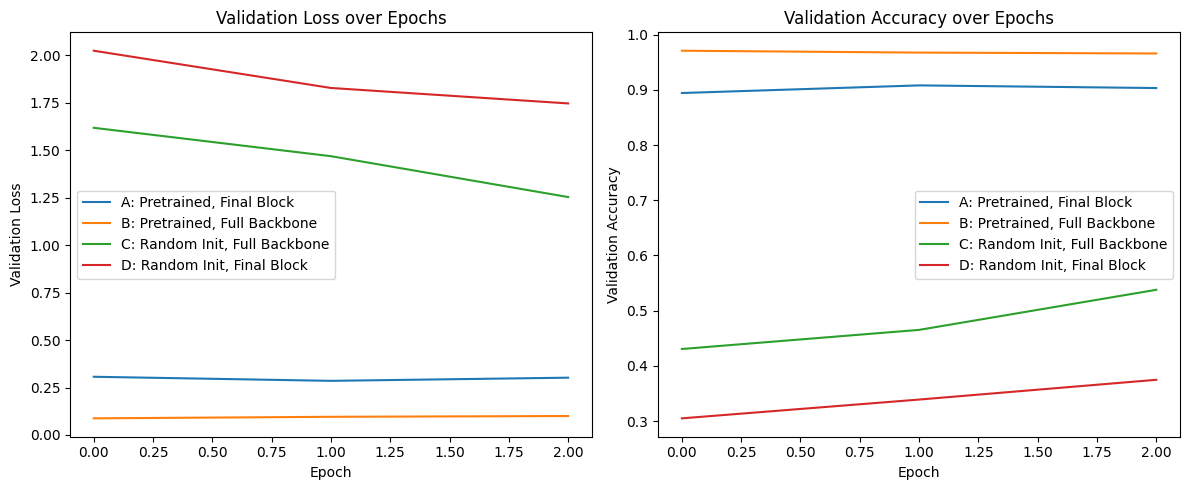

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

runs = {
    'A: Pretrained, Final Block': history_a,
    'B: Pretrained, Full Backbone': history_b,
    'C: Random Init, Full Backbone': history_c,
    'D: Random Init, Final Block': history_d,
}

for label, h in runs.items():
    axes[0].plot(h['val_loss'], label=label)
    axes[1].plot(h['val_acc'], label=label)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Validation Loss over Epochs')
axes[0].legend()

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy over Epochs')
axes[1].legend()

plt.tight_layout()
plt.savefig('CS-6304_PA0_28100131/results/task1_resnet/transfer_learning_comparison.png', dpi=150)
plt.show()


Saving results

In [59]:
transfer_results = {
    'run_a_pretrained_final_block': {'history': history_a, 'test_loss': test_loss_a, 'test_acc': test_acc_a, 'trainable_params': trainable_a},
    'run_b_pretrained_full_backbone': {'history': history_b, 'test_loss': test_loss_b, 'test_acc': test_acc_b, 'trainable_params': trainable_b},
    'run_c_random_full_backbone': {'history': history_c, 'test_loss': test_loss_c, 'test_acc': test_acc_c, 'trainable_params': trainable_c},
    'run_d_random_final_block': {'history': history_d, 'test_loss': test_loss_d, 'test_acc': test_acc_d, 'trainable_params': trainable_d},
}

with open('CS-6304_PA0_28100131/results/task1_resnet/transfer_learning_results.json', 'w') as f:
    json.dump(transfer_results, f, indent=2)

print("Transfer learning results saved.")


Transfer learning results saved.


Checking for Saved Files

In [60]:
print(os.listdir('CS-6304_PA0_28100131/results/task1_resnet'))

['baseline_results.json', 'tsne_late.png', 'baseline_training.png', 'tsne_early.png', 'transfer_learning_comparison.png', 'modified_training.png', 'baseline_head_weights.pt', 'modified_head_weights.pt', '.gitkeep', 'tsne_middle.png', 'modified_results.json', 'transfer_learning_results.json']


Git Configuration

In [61]:
!git config --global user.email "thebenbat5@gmail.com"
!git config --global user.name "TalhaShoyo10"

Commiting work to Github

In [62]:
commit_message = "Task 1 - Code for all subtasks set up"
!git -C {repo_name} add -A
!git -C {repo_name} commit -m "{commit_message}"
!git -C {repo_name} push https://{git_token}@github.com/{git_username}/{repo_name}.git main

[main 9d6ae77] Task 1 - Code for all subtasks set up
 2 files changed, 110 insertions(+)
 create mode 100644 results/task1_resnet/transfer_learning_comparison.png
 create mode 100644 results/task1_resnet/transfer_learning_results.json
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 2 threads
Compressing objects: 100% (6/6), done.
Writing objects: 100% (6/6), 80.33 KiB | 13.39 MiB/s, done.
Total 6 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/TalhaShoyo10/CS-6304_PA0_28100131.git
   b2c97b0..9d6ae77  main -> main
